# [실습] 단변량 분석

# 1.비즈니스 시나리오


- 고객사는 카시트 전문 판매 회사입니다.
    - 최근, 매출 그래프가 조금씩 아래로 향하기 시작했습니다. 회사의 여러 부서에서는 다양한 원인을 제시했지만, 그 원인들이 정말 데이터에 기반한 것인지는 여전히 의문입니다.

    - 부서별 문제 진단:
        - 가격 경쟁력 약화: 경쟁사와의 가격 경쟁에서 밀리고 있음
        - 광고비 집행 비효율: 광고비는 쓰고 있지만, 정말 적절하게 집행되지 않음
        - 국내 시장 편중: 해외 시장 개척은 뒷전이고, 국내 시장에만 집중됨
        - 지역 구매력 미파악: 지역별 구매력과 특성을 제대로 분석하지 못하고 있음

- 이 문제를 해결하기 위해 DX 프로젝트 팀이 빌딩되었습니다.
    - 여러분은 이 팀에서 데이터 분석을 책임지는 DX 컨설턴트로 합류했습니다.
    - 드디어 갈고 닦은 실력을 발휘할 기회가 주어졌습니다.
    - 자, 이제 단변량 분석을 통해 비즈니스 인사이트를 도출해 봅시다!
----
* 반복되는 코드는 함수로 만듭시다!
    * 함수를 만드는 순서
        * 먼저 절차대로 코드를 작성해서 실행한다.
        * 실행된 코드(오류가 없는 코드)를 가져다 함수로 구성한다.
            * 입력과 출력 결정

# 2.환경준비

## 2.1. 라이브러리 불러오기

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

## 2.2. 데이터 불러오기 : 카시트 판매량 데이터

|	변수명	|	설명	|	구분	|
|	----	|	----	|	----	|
|	Sales 	|	 각 지역 판매량(단위 : 1000개)	|	Target	|
|	CompPrice 	|	 경쟁사 가격(단위 : 달러)	|	feature	|
|	Income 	|	 지역 평균 소득(단위 : 1000달러)	|	feature	|
|	Advertising 	|	 각 지역, 회사의 광고 예산(단위 : 1000달러)	|	feature	|
|	Population 	|	 지역 인구수(단위 : 1000명)	|	feature	|
|	Price 	|	 자사 지역별 판매가격	|	feature	|
|	ShelveLoc 	|	 진열상태	|	feature	|
|	Age 	|	 지역 인구의 평균 연령	|	feature	|
|	Urban 	|	 도심 지역 여부(Yes,No)	|	feature	|
|	US 	|	 매장이 미국에 있는지 여부(Yes,No)	|	feature	|


In [ ]:
df = pd.read_csv('data/Carseats.csv')
df

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Urban,US
0,9.50,138,73,11,276,120,Bad,42,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,Yes,No


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Sales        400 non-null    float64
 1   CompPrice    400 non-null    int64  
 2   Income       400 non-null    int64  
 3   Advertising  400 non-null    int64  
 4   Population   400 non-null    int64  
 5   Price        400 non-null    int64  
 6   ShelveLoc    400 non-null    str    
 7   Age          400 non-null    int64  
 8   Urban        400 non-null    str    
 9   US           400 non-null    str    
dtypes: float64(1), int64(6), str(3)
memory usage: 31.4 KB


In [4]:
df.describe()

,Sales,CompPrice,Income,Advertising,Population,Price,Age
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,7.496325,124.975000,68.657500,6.635000,264.840000,115.795000,53.322500
std,2.824115,15.334512,27.986037,6.650364,147.376436,23.676664,16.200297
min,0.000000,77.000000,21.000000,0.000000,10.000000,24.000000,25.000000
25%,5.390000,115.000000,42.750000,0.000000,139.000000,100.000000,39.750000
50%,7.490000,125.000000,69.000000,5.000000,272.000000,117.000000,54.500000
75%,9.320000,135.000000,91.000000,12.000000,398.500000,131.000000,66.000000
max,16.270000,175.000000,120.000000,29.000000,509.000000,191.000000,80.000000


# 3.단변량 분석 : 숫자형 변수

In [5]:
# 숫자형 변수에 대한 단변량 분석 함수
def eda_1_n(var, data, bins = 30):
    # 기초 통계량
    display(data[[var]].describe().T)

    # 시각화
    plt.figure(figsize = (12,8))
    plt.subplot(2,1,1)
    sns.histplot(data[var], bins = bins, kde = True)
    plt.grid()
    plt.subplot(2,1,2)
    sns.boxplot(x = data[var])
    plt.grid()
    plt.show()

## 3.1. Sales (Target)

In [6]:
var = 'Sales'

1) 변수의 비즈니스 의미

* 각 지역 판매량(단위 : 1000개)
* Target

2) 기초통계량(수치화)

In [7]:
df[[var]].describe().T

,count,mean,std,min,25%,50%,75%,max
Sales,400.0,7.496325,2.824115,0.0,5.39,7.49,9.32,16.27


3) 분포 확인(시각화)

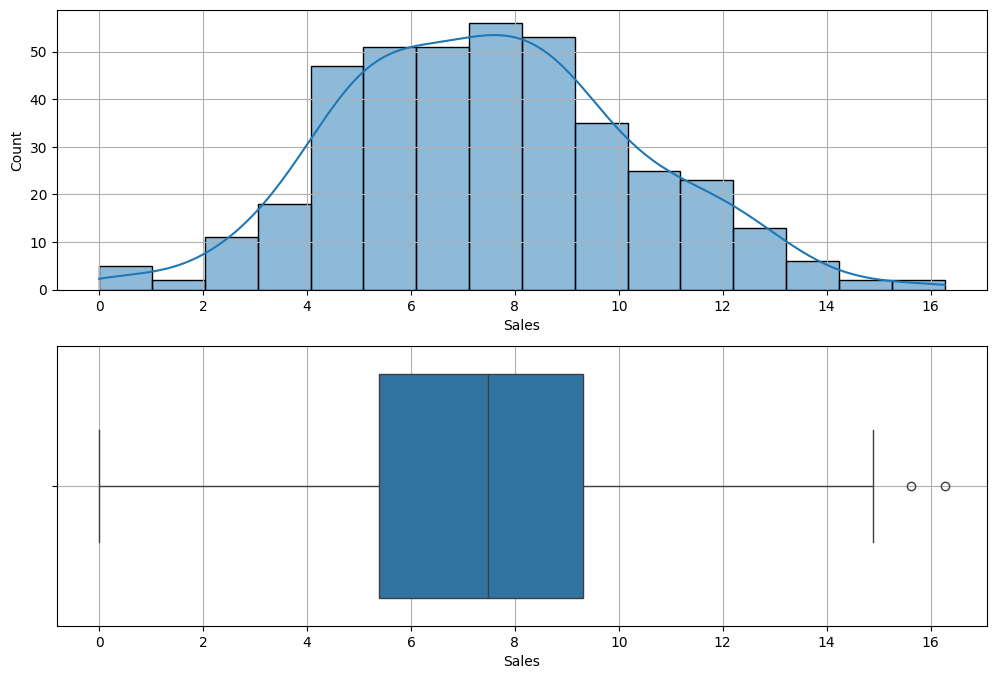

In [8]:
plt.figure(figsize=(12,8))
plt.subplot(2,1,1)
sns.histplot(x=var, data=df, kde=True)
plt.grid()

plt.subplot(2,1,2)
sns.boxplot(x=var, data=df)
plt.grid()
plt.show()

4) 기초통계량과 분포를 통해서 파악한 내용을 적어 봅시다.

보이는 그대로를 넘어, 비즈니스 관점에서 고민하며 적어 봅시다.

- 판매량 분포는 비교적 대칭적이며 대부분 중간값에 몰려 있다.
- 각 지역 판매량의 50%가 약 5천개에서 9천개 사이에 형성된다.
- 높은 판매량을 기록한 일부 매장은 특정 요인(광고, 위치, 선반 품질 등)이 영향을 미쳤을 가능성이 있다.

5) 추가 분석해 볼 사항이 있나요?

- 각 지역에 대한 구체적 요인(인구수, 경제수준, 광고 여부) 파악 필요.
- 판매량 구간을 0 ~ 4천, 4천 ~ 1만, 1만 이상 으로 구분해서 분석해 볼 필요 있음.
- 높은 판매량을 기록한 매장들의 공통점 파악.

## 3.2. CompPrice

In [9]:
var='CompPrice'

1) 변수의 비즈니스 의미

- 경쟁사 가격(단위:달러)

2) 기초통계량(수치화)

In [11]:
df[[var]].describe().T

,count,mean,std,min,25%,50%,75%,max
CompPrice,400.0,124.975,15.334512,77.0,115.0,125.0,135.0,175.0


3) 분포 확인(시각화)

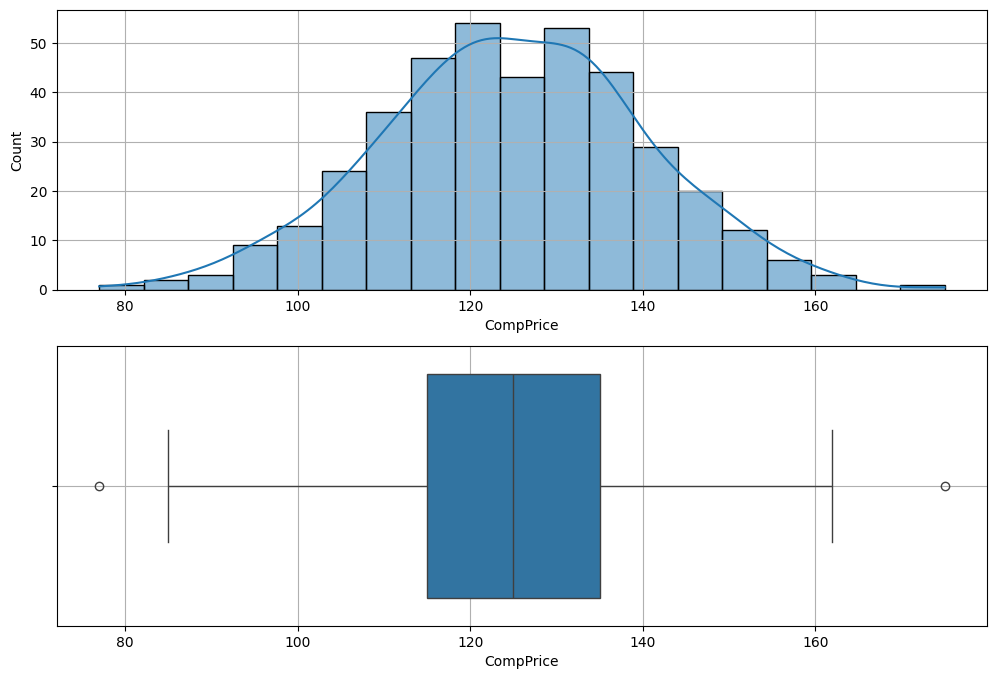

In [12]:
plt.figure(figsize=(12,8))
plt.subplot(2,1,1)
sns.histplot(x=var, data=df, kde=True)
plt.grid()

plt.subplot(2,1,2)
sns.boxplot(x=var, data=df)
plt.grid()
plt.show()

4) 기초통계량과 분포를 통해서 파악한 내용을 적어 봅시다.

보이는 그대로를 넘어, 비즈니스 관점에서 고민하며 적어 봅시다.

- 경쟁사 카시트 가격의 전체 범위는 77 ~  175달러
- 제품 종류에 가격대가 차이가 있지 않을까?
- 경쟁 매장 가격이 비정상적으로 낮거나 높은 경우, 시장 내 특정 가격 전략(저가 공략, 프리미엄 전략 등)이 작용했을 가능성이 있음

5) 추가 분석해 볼 사항이 있나요?

- 자사 가격과 비교
    - 전체 분포 비교
    - 지역별 가격 비교
- 경쟁 매장의 가격 전략이 판매량에 미친 영향 파악

## 3.3. Income

In [38]:
var = 'Income'

1) 변수의 비즈니스 의미

- 지역 평균 소득(단위: 1000달러)

2) 기초통계량(수치화)

In [15]:
df[['Income']].describe().T

,count,mean,std,min,25%,50%,75%,max
Income,400.0,68.6575,27.986037,21.0,42.75,69.0,91.0,120.0


3) 분포 확인(시각화)

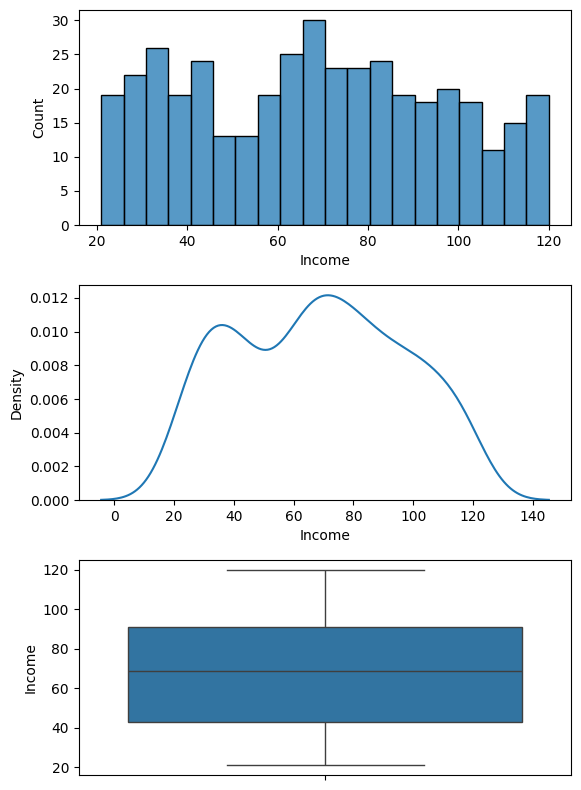

In [16]:
plt.figure(figsize = (6,8))
plt.subplot(3,1,1)
sns.histplot(df[var], bins = 20)

plt.subplot(3,1,2)
sns.kdeplot(df[var])
df
plt.subplot(3,1,3)
sns.boxplot(df[var])

plt.tight_layout()
plt.show()

,count,mean,std,min,25%,50%,75%,max
Income,400.0,68.6575,27.986037,21.0,42.75,69.0,91.0,120.0


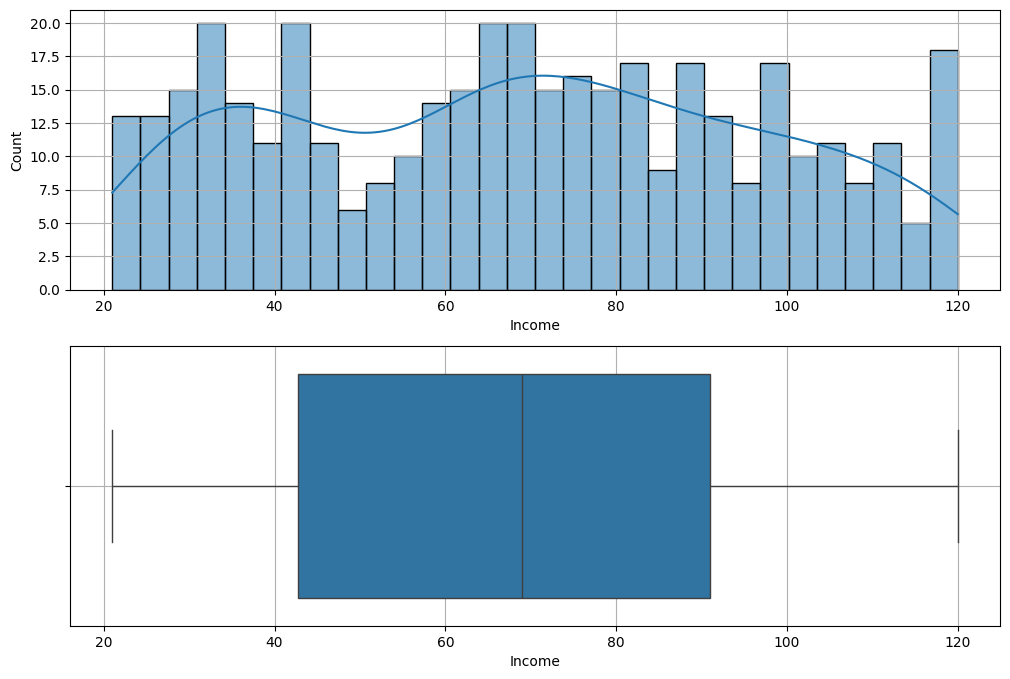

In [17]:
# 함수사용
eda_1_n('Income', df)

4) 기초통계량과 분포를 통해서 파악한 내용을 적어 봅시다.

보이는 그대로를 넘어, 비즈니스 관점에서 고민하며 적어 봅시다.

- 특정 소득층에만 몰린 것이 아니라 여러 생활권을 고르게 담고 있는 구조이다. 
- 2만달러 ~ 12만 달러 이므로 연간 소득일 것.
- 50%가 약 4만달러 ~ 9만달러

5) 추가 분석해 볼 사항이 있나요?

- 평균 소득과 카시트 판매량과의 관계
- 평균 소득과 카시트 가격과의 관계
- 특정 소득 수준에서 판매량이 더 높은지 확인 필요

## 3.4. Advertising

In [18]:
var = 'Advertising'

1) 변수의 비즈니스 의미

- 각 지역, 회사의 광고 예산(단위:1000달러)

2) 기초통계량(수치화)

In [19]:
df[[var]].describe().T

,count,mean,std,min,25%,50%,75%,max
Advertising,400.0,6.635,6.650364,0.0,0.0,5.0,12.0,29.0


3) 분포 확인(시각화)

,count,mean,std,min,25%,50%,75%,max
Advertising,400.0,6.635,6.650364,0.0,0.0,5.0,12.0,29.0


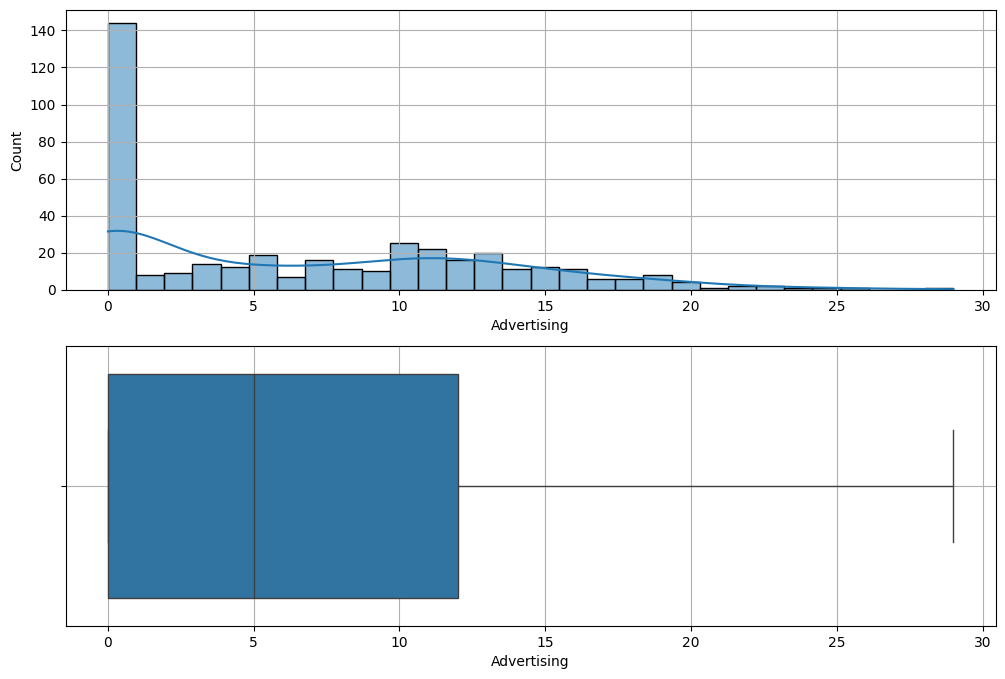

In [20]:
eda_1_n(var, df)

In [21]:
# temp = df.loc[df[var]]
temp = df.loc[df[var] > 0]

In [40]:
# 광고비 예산이 0인 지역 비율
df.loc[df['Advertising']==0].shape[0]/df.shape[0]*100

36.0

4) 기초통계량과 분포를 통해서 파악한 내용을 적어 봅시다.

보이는 그대로를 넘어, 비즈니스 관점에서 고민하며 적어 봅시다.

- 25%까지 0인것을 봐서 회사가 광고비를 안쓴다.
- 아니면 광고를 제대로 못하고 있는 듯?
- 광고비 예산이 0 인 지역이 전체에 36%나 됨.
- 광고비 지출이 판매량 증가에 긍정적 영향을 미치는지 확인이 필요함.

5) 추가 분석해 볼 사항이 있나요?

- 광고비 예산 0을 제외하고 분포 확인 필요.
- 아예 안하는 매장과 집행하는 매장을 나눠서 분석.
- 광고 효율보다는 먼저 광조 집행 여부 자체가 전략 변수일 수 있음. 

## 3.5. Population

1) 변수의 비즈니스 의미

- 지역 인구수(단위:1000명)

2) 기초통계량(수치화)

,count,mean,std,min,25%,50%,75%,max
Population,400.0,264.84,147.376436,10.0,139.0,272.0,398.5,509.0


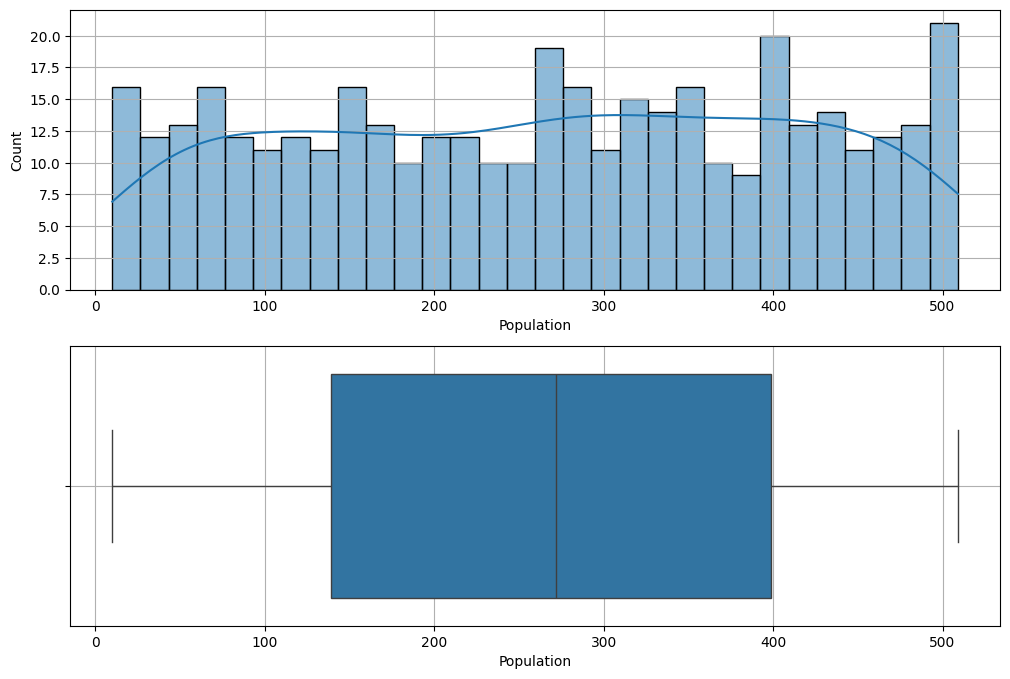

In [22]:
eda_1_n('Population', df)

3) 분포 확인(시각화)

4) 기초통계량과 분포를 통해서 파악한 내용을 적어 봅시다.

보이는 그대로를 넘어, 비즈니스 관점에서 고민하며 적어 봅시다.

- 상권 인구가 크다고 해서 반드시 매출이 높다고 단정할 수는 없고, 인구 많아도 경쟁이 치열하거나 구매력이 낮을 수 있다. 
- 시장 크기 후보 변수. 단독으로는 설명력 제한될 수 있음. 

5) 추가 분석해 볼 사항이 있나요?

- 인구 자체보다 가구 수, 영유아 비중, 출산율, 가족 단위 비중 같은 변수와 결합하는 것이 좋습니다.
- 인구수에 따른 판매량 관계
- 인구수와 평균연령의 관계

## 3.6. Price

1) 변수의 비즈니스 의미

- 자사 지역별 판매가격


2) 기초통계량(수치화)

3) 분포 확인(시각화)

,count,mean,std,min,25%,50%,75%,max
Price,400.0,115.795,23.676664,24.0,100.0,117.0,131.0,191.0


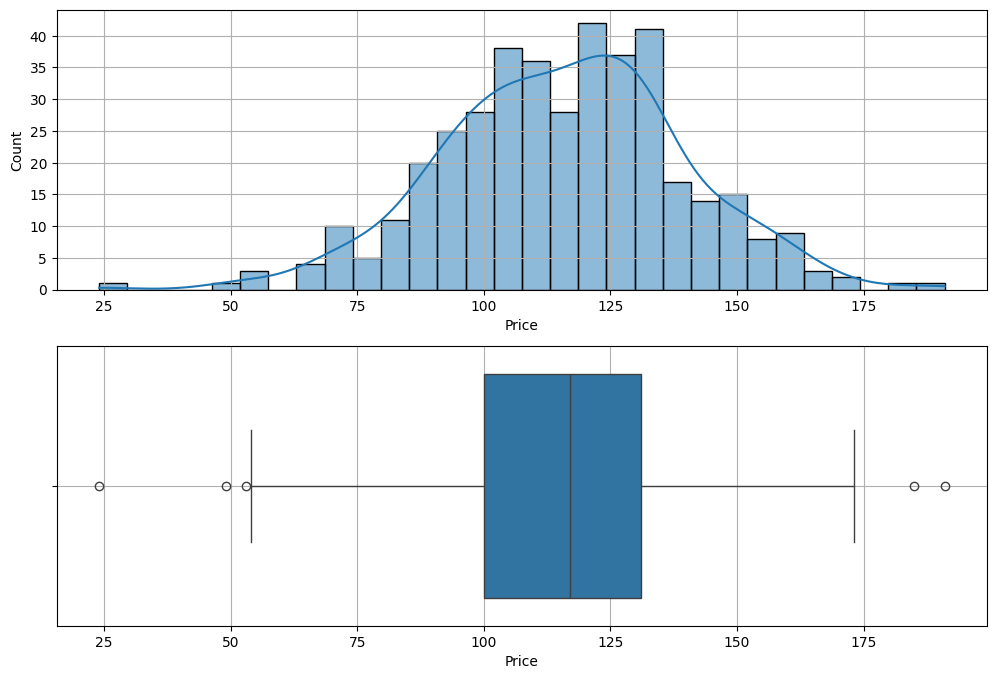

In [23]:
eda_1_n('Price', df)

4) 기초통계량과 분포를 통해서 파악한 내용을 적어 봅시다.

보이는 그대로를 넘어, 비즈니스 관점에서 고민하며 적어 봅시다.

- 가격대가 24 ~ 191 달러로 경쟁사보다 범위가 넓다.
- 50%는 100 ~ 130 사이.

5) 추가 분석해 볼 사항이 있나요?

- 가격에 따라 판매량은 달라질까?
- 자사 가격과 경쟁사 가격 비교
- 최적 가격 포인트 도출을 위한 분석 필요

(추가) Price vs CompPrice

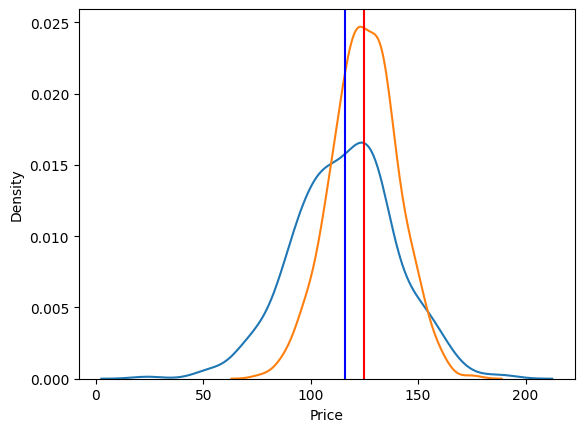

In [41]:
# 밀도 함수
sns.kdeplot(x='Price', data=df)  # 기본색 : 첫번째 - 파랑
sns.kdeplot(x='CompPrice', data=df)   # 두번째 - 주황

pr_mean = df['Price'].mean()
cpr_mean = df['CompPrice'].mean()

plt.axvline(pr_mean , color = 'b')   # 자사 가격 평균
plt.axvline(cpr_mean,  color = 'r' )  # 타사 가격 평균
plt.show()

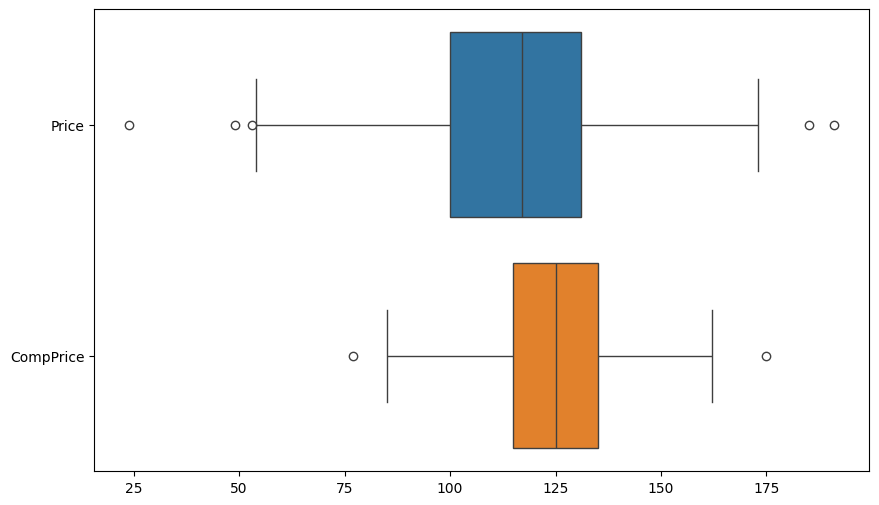

In [42]:
# 박스플롯
plt.figure(figsize = (10,6))
sns.boxplot(data=df[['Price','CompPrice']], orient="h")
plt.show()

## 3.7. Age

1) 변수의 비즈니스 의미

- 지역 인구의 평균 연령

2) 기초통계량(수치화)

In [24]:
df[['Age']].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,400.0,53.3225,16.200297,25.0,39.75,54.5,66.0,80.0


3) 분포 확인(시각화)

,count,mean,std,min,25%,50%,75%,max
Age,400.0,53.3225,16.200297,25.0,39.75,54.5,66.0,80.0


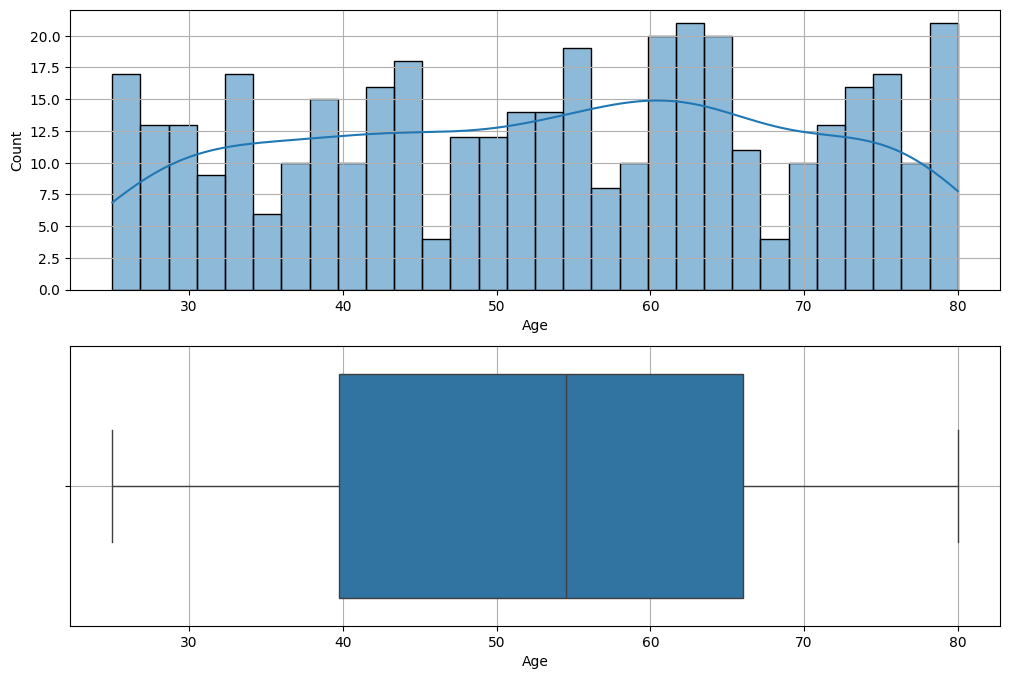

In [25]:
eda_1_n('Age', df)

4) 기초통계량과 분포를 통해서 파악한 내용을 적어 봅시다.

보이는 그대로를 넘어, 비즈니스 관점에서 고민하며 적어 봅시다.

- 지역별 평균나이는 거의 균등분포로 보임
- 연령대별로 선호하는 제품이나 마케팅 전략이 다를 가능성이 있음
- 평균나이
    - 지역 인구 전체에 대한 평균
    - 카시트가 필요한 사람은, 약 10세 이하 자녀를 둔 부모
    - 10세 이하 자녀들과 20대후반 ~ 40세의 부모가 주축인 인구의 평균 나이는?
- `age`는 단순한 인구 통계가 아니라 잠재 수요층의 생애주기 구조를 간접 반영할 수 있음.

5) 추가 분석해 볼 사항이 있나요?

- 평균 결혼 나이와 첫 자녀 출산 나이 파악
- 가장 판매량이 높은 평균나이는?
- 실제로는 평균 연령보다 영유아 가구 비중과 연결해보는 것이 더 좋음. 평균 연령만으로는 가족 구조를 정확히 설명하기 어렵기 때문.

# 4.단변량 분석 : 범주형 변수

In [26]:
# 범주형 변수에 대한 단변량 분석 함수
def eda_1_c(var, data) :
    # 기초 통계량
    cnt = data[var].value_counts()
    prop = data[var].value_counts()/data.shape[0]
    temp = pd.DataFrame({'Class':cnt.index, 'Count':cnt.values, 'Prop':prop.values})
    display(temp)

    # 시각화
    sns.countplot(x = var, data = data)
    plt.grid()
    plt.show()

## 4.1. Urban

1) 변수의 비즈니스 의미

- 도심 지역 여부(Yes, No)

2) 기초통계량(수치화)

In [27]:
df[['Urban']].value_counts()

Urban
Yes      282
No       118
Name: count, dtype: int64

In [28]:
df[['Urban']].value_counts()/df.shape[0]

Urban
Yes      0.705
No       0.295
Name: count, dtype: float64

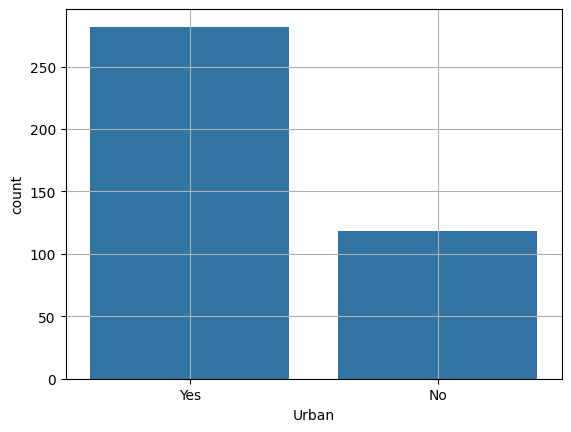

In [29]:
sns.countplot(x='Urban',data=df)
plt.grid()
plt.show()

3) 분포 확인(시각화)

4) 기초통계량과 분포를 통해서 파악한 내용을 적어 봅시다.

보이는 그대로를 넘어, 비즈니스 관점에서 고민하며 적어 봅시다.

- 약 70% 매장이 도시에 있음. 표본이 도시 쪽에 다소 치우쳐 있음.
- 도시 매장이 많다는 것은 이 데이터에서 전체 평균을 볼 때 도시 특성이 더 많이 반영될 가능성이 있다는 뜻. 

5) 추가 분석해 볼 사항이 있나요?

- 도시/비도시별로 가격, 광고비, 인구수 등을 비교할 필요 있음. 
- 특히 카시트는 차량 보유 패턴, 대형마트 접근성, 가족 이동 패턴과도 관련될 수 있음.

## 4.2. ShelveLoc

1) 변수의 비즈니스 의미

* 매장 진열상태

2) 기초통계량(수치화)

In [30]:
df[['ShelveLoc']].value_counts()

ShelveLoc
Medium       219
Bad           96
Good          85
Name: count, dtype: int64

In [31]:
df[['ShelveLoc']].value_counts()/df.shape[0]

ShelveLoc
Medium       0.5475
Bad          0.2400
Good         0.2125
Name: count, dtype: float64

3) 분포 확인(시각화)

,Class,Count,Prop
0,Medium,219,0.5475
1,Bad,96,0.2400
2,Good,85,0.2125


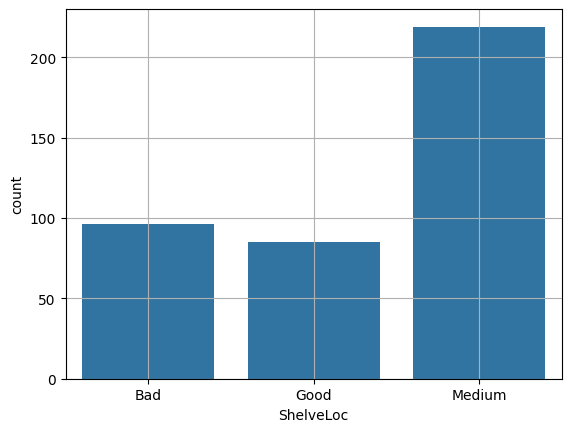

In [32]:
eda_1_c('ShelveLoc',df)

4) 기초통계량과 분포를 통해서 파악한 내용을 적어 봅시다.

보이는 그대로를 넘어, 비즈니스 관점에서 고민하며 적어 봅시다.

- 대부분의 제품이 Medium 선반에 진열됨.
- 선반 품질이 판매량에 미치는 영향이 클 수 있음.

5) 추가 분석해 볼 사항이 있나요?

- 진열상태에 따른 판매량 차이
- 지역, 인구수와 진열 상태 관계 비교

## 4.3. US

In [33]:
var = 'US'

1) 변수의 비즈니스 의미

- 매장이 미국에 있는지 여부(Yes, No)

2) 기초통계량(수치화)

In [34]:
# 범주별 빈도수
df[var].value_counts()

US
Yes    258
No     142
Name: count, dtype: int64

In [35]:
# 범주별 비율
df[var].value_counts() / df[var].shape[0]

US
Yes    0.645
No     0.355
Name: count, dtype: float64

3) 분포 확인(시각화)

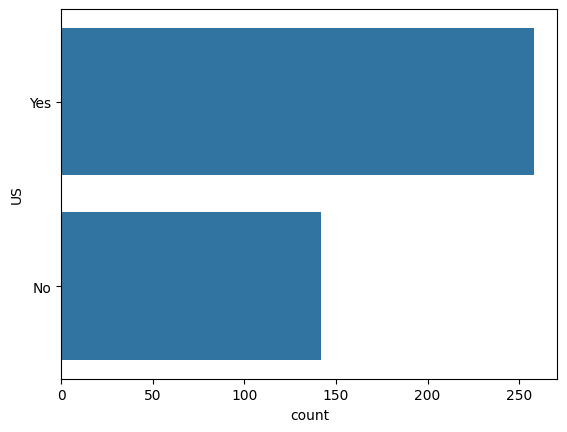

In [36]:
sns.countplot(df[var], order = ['Yes', 'No'])
plt.show()

,Class,Count,Prop
0,Yes,258,0.645
1,No,142,0.355


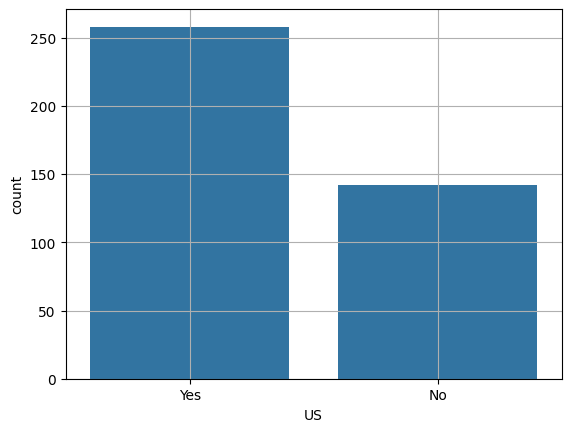

In [37]:
eda_1_c(var,df)

4) 기초통계량과 분포를 통해서 파악한 내용을 적어 봅시다.

보이는 그대로를 넘어, 비즈니스 관점에서 고민하며 적어 봅시다.

- 약 65% 미국. 미국/비미국 차이는 단순 지역 정보가 아니라 유통 채널, 규제, 소비자 선호, 가격대, 프로모션 관행까지 함축할 수 있음.

5) 추가 분석해 볼 사항이 있나요?

- 국내외 매장 광고비, 판매가, 경쟁사가격, 매출액 등 비교
- 국가별 매장 특성 파악 및 전략 수립
- 필요하면 환율, 소득수준, 시장 구조 차이를 반영한 해석도 추가해야 됨. 